<a href="https://colab.research.google.com/github/crowell97/ES5201/blob/main/ES5201_Lecture8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Synthetic Seismograms & Finite Differences — A Companion Notebook

**EARTH 5201 — Introduction to Seismology**

**The Ohio State University**

**Companion notebook to Lecture 8 — Synthetic Seismograms & the Finite-Difference Method**

This notebook turns the lecture's derivations into working code:

1. **The elastodynamic Green's function** — a real computed illustration of point source → response → convolution.
2. **Finite-difference formulas from scratch** — implementing and verifying the forward, backward, and central difference approximations derived by hand in lecture, including their truncation error scaling.
3. **A complete 1-D SH-wave finite-difference simulator** — the staggered-grid, velocity-stress scheme derived in lecture, actually propagating a wave through a medium with an impedance contrast.
4. **Numerical stability** — a short, hands-on look at the CFL condition that determines whether a finite-difference scheme blows up or not.

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pylab as plt

plt.rcParams["figure.figsize"] = (9, 4)

## Part 1 — The Elastodynamic Green's Function

For the 1-D boundary value problem $-u''(x) = f(x)$ with $u(0)=u(1)=0$, the Green's function is the classic triangular "tent" function:

$$G(x, x') = \begin{cases} x(1-x') & x \le x' \\ x'(1-x) & x > x' \end{cases}$$

Once we have $G$, the response to *any* source $f(x)$ follows by convolution — no need to re-solve the differential equation from scratch for every new source.

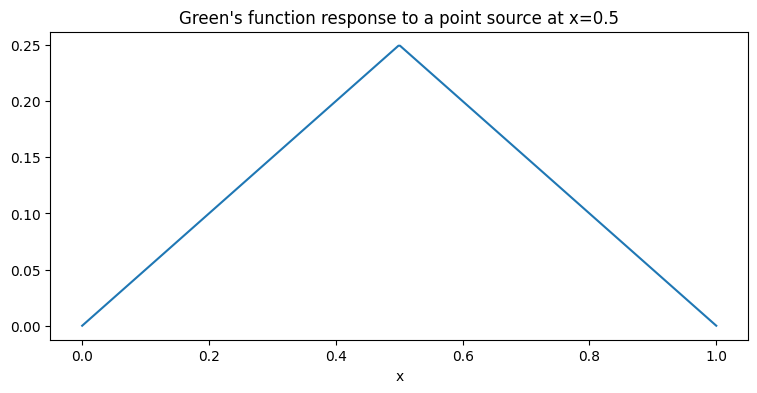

In [2]:
def green_point(x, xp):
    """1-D Green's function for -u'' = f, u(0)=u(1)=0."""
    return np.where(x <= xp, x * (1 - xp), xp * (1 - x))

x = np.linspace(0, 1, 400)
x0 = 0.5

G = green_point(x, x0)
plt.plot(x, G)
plt.title(f"Green's function response to a point source at x={x0}")
plt.xlabel("x")
plt.show()

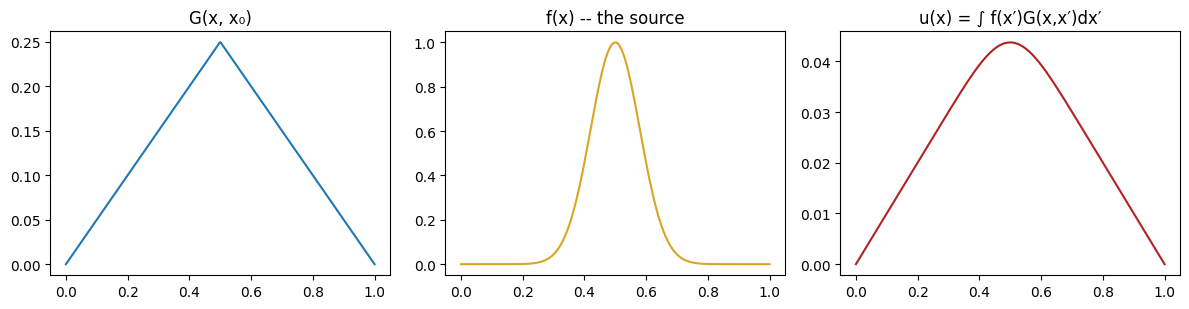

In [3]:
# A general (smooth) source -- a Gaussian bump
f = np.exp(-((x - 0.5) ** 2) / (2 * 0.08 ** 2))

# u(x) = integral of f(x') G(x, x') dx'  -- numerical convolution with the Green's function
dx = x[1] - x[0]
u = np.zeros_like(x)
for i, xi in enumerate(x):
    Gx = green_point(xi, x)
    u[i] = np.sum(f * Gx) * dx

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
axes[0].plot(x, G); axes[0].set_title("G(x, x\u2080)")
axes[1].plot(x, f, color="goldenrod"); axes[1].set_title("f(x) -- the source")
axes[2].plot(x, u, color="firebrick"); axes[2].set_title("u(x) = \u222b f(x\u2032)G(x,x\u2032)dx\u2032")
plt.tight_layout()
plt.show()

### Checking the answer directly

Since $u$ solves $-u''=f$ with $u(0)=u(1)=0$, we can sanity-check the convolution result by taking a numerical second derivative of `u` and comparing it to `-f`.

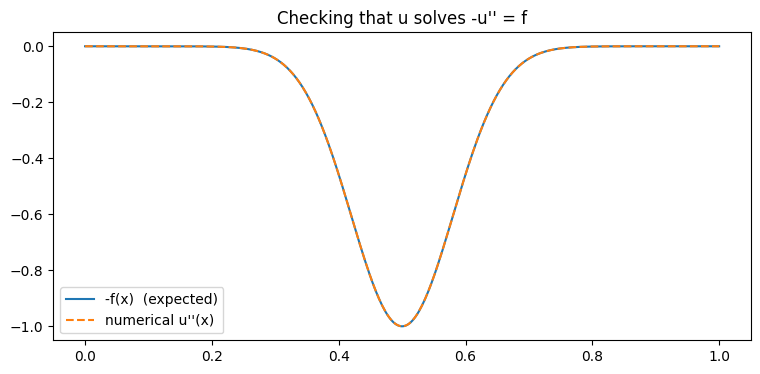

In [4]:
d2u_dx2 = np.gradient(np.gradient(u, x), x)

plt.plot(x, -f, label="-f(x)  (expected)")
plt.plot(x, d2u_dx2, "--", label="numerical u''(x)")
plt.legend()
plt.title("Checking that u solves -u'' = f")
plt.show()

## Part 2 — Finite-Difference Formulas from Scratch

Lecture 8 derived the forward, backward, and central difference formulas directly from a Taylor expansion. Let's implement all three and check them against a function whose derivative we know exactly: $\phi(x) = \sin(x)$, with $\phi'(x) = \cos(x)$.

In [5]:
def forward_diff(phi, x, dx):
    return (phi(x + dx) - phi(x)) / dx

def backward_diff(phi, x, dx):
    return (phi(x) - phi(x - dx)) / dx

def central_diff(phi, x, dx):
    return (phi(x + dx) - phi(x - dx)) / (2 * dx)

def second_deriv(phi, x, dx):
    return (phi(x + dx) + phi(x - dx) - 2 * phi(x)) / dx**2

phi = np.sin
x0 = 1.0
dx = 0.1

print(f"True derivative cos({x0}) = {np.cos(x0):.6f}")
print(f"Forward difference:        {forward_diff(phi, x0, dx):.6f}")
print(f"Backward difference:       {backward_diff(phi, x0, dx):.6f}")
print(f"Central difference:        {central_diff(phi, x0, dx):.6f}")
print()
print(f"True second derivative -sin({x0}) = {-np.sin(x0):.6f}")
print(f"Finite-difference second derivative: {second_deriv(phi, x0, dx):.6f}")

True derivative cos(1.0) = 0.540302
Forward difference:        0.497364
Backward difference:       0.581441
Central difference:        0.539402

True second derivative -sin(1.0) = -0.841471
Finite-difference second derivative: -0.840770


### Truncation error scaling

Lecture derived that the forward/backward differences have error of order $\Delta x$, while the central difference and second-derivative formulas have error of order $(\Delta x)^2$. Let's confirm this empirically by sweeping $\Delta x$ and plotting the error on a log-log scale — the slopes should be 1 and 2, respectively.

<>:9: SyntaxWarning: invalid escape sequence '\D'
<>:10: SyntaxWarning: invalid escape sequence '\D'
<>:11: SyntaxWarning: invalid escape sequence '\D'
<>:9: SyntaxWarning: invalid escape sequence '\D'
<>:10: SyntaxWarning: invalid escape sequence '\D'
<>:11: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_3508/3454245015.py:9: SyntaxWarning: invalid escape sequence '\D'
  plt.loglog(dxs, dxs, "--", color="gray", label="O($\Delta x$)")
/tmp/ipykernel_3508/3454245015.py:10: SyntaxWarning: invalid escape sequence '\D'
  plt.loglog(dxs, dxs**2, ":", color="gray", label="O($\Delta x^2$)")
/tmp/ipykernel_3508/3454245015.py:11: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel("$\Delta x$"); plt.ylabel("absolute error")


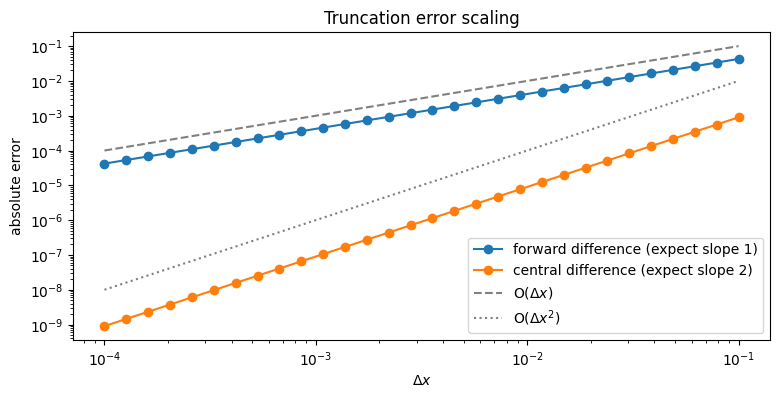

Forward-difference error scales as (Δx)^1.00  (expected ~1)
Central-difference error scales as (Δx)^2.00  (expected ~2)


In [6]:
dxs = np.logspace(-4, -1, 30)
true_deriv = np.cos(x0)

err_forward = [abs(forward_diff(phi, x0, dx) - true_deriv) for dx in dxs]
err_central = [abs(central_diff(phi, x0, dx) - true_deriv) for dx in dxs]

plt.loglog(dxs, err_forward, "o-", label="forward difference (expect slope 1)")
plt.loglog(dxs, err_central, "o-", label="central difference (expect slope 2)")
plt.loglog(dxs, dxs, "--", color="gray", label="O($\Delta x$)")
plt.loglog(dxs, dxs**2, ":", color="gray", label="O($\Delta x^2$)")
plt.xlabel("$\Delta x$"); plt.ylabel("absolute error")
plt.legend()
plt.title("Truncation error scaling")
plt.show()

# Fit the slope on a log-log plot to confirm the order of accuracy
slope_forward = np.polyfit(np.log(dxs), np.log(err_forward), 1)[0]
slope_central = np.polyfit(np.log(dxs), np.log(err_central), 1)[0]
print(f"Forward-difference error scales as (\u0394x)^{slope_forward:.2f}  (expected ~1)")
print(f"Central-difference error scales as (\u0394x)^{slope_central:.2f}  (expected ~2)")

## Part 3 — A 1-D SH-Wave Finite-Difference Simulator

Now the payoff: implementing the exact staggered-grid, velocity-stress scheme derived in lecture,

$$\frac{\partial \dot v}{\partial t} = \frac{1}{\rho(x)}\frac{\partial \tau}{\partial x}, \qquad \frac{\partial \tau}{\partial t} = \mu(x)\frac{\partial \dot v}{\partial x}$$

and using it to propagate a real SH pulse through a medium with an impedance contrast — the same physical setup as the reflection/transmission problem from Lecture 6, but now solved numerically instead of analytically.

In [7]:
# Grid setup
L = 20.0
nx = 401
dx = L / (nx - 1)
x = np.linspace(0, L, nx)

# Material properties: a density jump at x=10, constant shear modulus
# (mirrors the two-string reflection/transmission example from Lecture 6)
rho = np.where(x < 10, 3.0, 6.0)
mu = np.ones(nx) * 9.0   # shear modulus, constant
c_local = np.sqrt(mu / rho)
print(f"Wave speed on the left:  {c_local[0]:.3f}")
print(f"Wave speed on the right: {c_local[-1]:.3f}")

Wave speed on the left:  1.732
Wave speed on the right: 1.225


In [8]:
# Time step from the CFL stability condition (see Part 4)
courant = 0.5
dt = courant * dx / c_local.max()
nt = 500

# Fields on the staggered grid: velocity v at integer grid points,
# stress tau at half-integer grid points (nx-1 of them)
v = np.zeros(nx)
tau = np.zeros(nx - 1)

# Launch a smooth velocity pulse near the left edge
x0, width = 4.0, 0.4
v += np.exp(-((x - x0) ** 2) / (2 * width ** 2))

snapshots = [v.copy()]
snap_times = [0]

for n in range(1, nt):
    # Update stress at half-integer points from the velocity gradient
    dv_dx = (v[1:] - v[:-1]) / dx
    tau += dt * mu[:-1] * dv_dx   # mu evaluated at the left of each stress node (simple choice)

    # Update velocity at interior integer points from the stress gradient
    dtau_dx = (tau[1:] - tau[:-1]) / dx
    v[1:-1] += dt * dtau_dx / rho[1:-1]

    # Fixed (zero-velocity) boundaries
    v[0] = v[-1] = 0.0

    if n % 25 == 0:
        snapshots.append(v.copy())
        snap_times.append(n)

print(f"Simulated {nt} time steps, dt={dt:.4f}, stored {len(snapshots)} snapshots")

Simulated 500 time steps, dt=0.0144, stored 20 snapshots


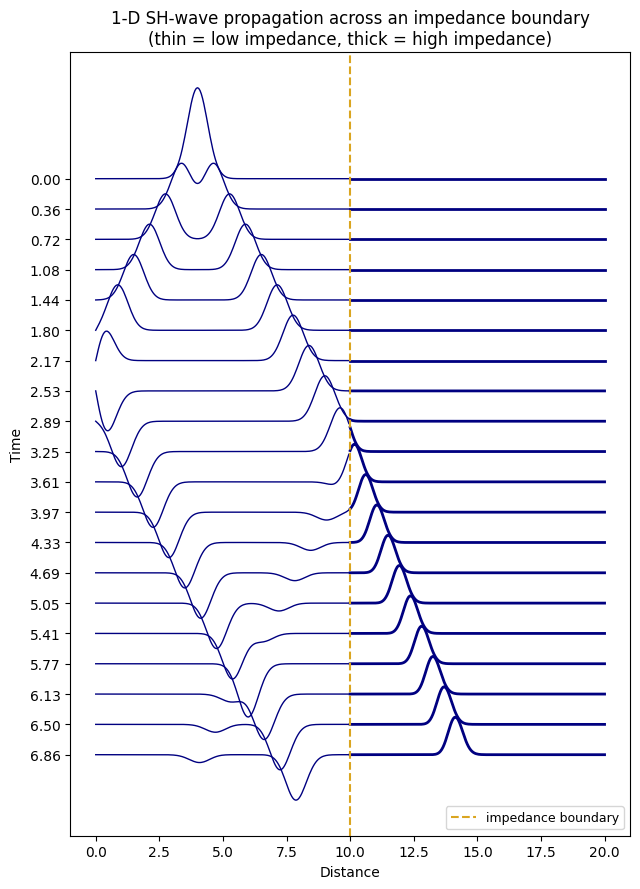

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 9))
for i, snap in enumerate(snapshots):
    y_off = -i * 1.0
    left, right = x < 10, x >= 10
    ax.plot(x[left], snap[left] * 3 + y_off, color="navy", linewidth=1)
    ax.plot(x[right], snap[right] * 3 + y_off, color="navy", linewidth=2)
ax.axvline(10, color="goldenrod", linestyle="--", label="impedance boundary")
ax.set_yticks(-np.arange(len(snapshots)))
ax.set_yticklabels([f"{t*dt:.2f}" for t in snap_times])
ax.set_xlabel("Distance"); ax.set_ylabel("Time")
ax.set_title("1-D SH-wave propagation across an impedance boundary\n(thin = low impedance, thick = high impedance)")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

Notice the same qualitative behavior derived analytically in Lecture 6: part of the pulse reflects (with reduced amplitude) back into the low-impedance region, and part transmits into the high-impedance region — but now it comes directly out of the finite-difference simulation, with no reflection/transmission coefficients assumed in advance.

(You'll also notice the initial velocity pulse splits into two counter-propagating lobes — one heading left, one heading right. This is expected: starting from a pure velocity perturbation with zero initial stress is like plucking a string, which launches equal-amplitude waves in both directions, exactly as in Lecture 6's normal-mode discussion.)

### Measuring the wave speed from the simulation

As a sanity check, we can measure how far the right-moving lobe's peak travels between two snapshots and compare it to the analytic wave speed $c=\sqrt{\mu/\rho}$. We restrict the search to $x > x_0$ so we're only tracking the right-moving lobe, and use snapshots taken after the two lobes have clearly separated.

In [10]:
# Track only the right-moving lobe (restrict the search to x > x0, away from
# the left-moving lobe and the fixed boundary), using snapshots once the two
# lobes have clearly separated
def peak_position(snap, region_mask):
    idx = np.argmax(np.abs(snap[region_mask]))
    return x[region_mask][idx]

right_region = (x > x0 + 0.3) & (x < 9)
p0 = peak_position(snapshots[2], right_region)
p1 = peak_position(snapshots[6], right_region)
dt_elapsed = (snap_times[6] - snap_times[2]) * dt

measured_speed = (p1 - p0) / dt_elapsed
print(f"Measured wave speed: {measured_speed:.3f}")
print(f"Analytic wave speed (sqrt(mu/rho)): {c_local[0]:.3f}")

Measured wave speed: 1.732
Analytic wave speed (sqrt(mu/rho)): 1.732


## Part 4 — Numerical Stability: The CFL Condition

Finite-difference time-stepping schemes aren't unconditionally stable — the time step $\Delta t$ must be small enough relative to $\Delta x$ and the wave speed, or the simulation blows up. This is the Courant-Friedrichs-Lewy (CFL) condition:

$$\text{Courant number} = \frac{c\,\Delta t}{\Delta x} \le 1$$

Let's see this fail in real time by deliberately choosing a Courant number greater than 1.

In [11]:
def run_sh_simulation(courant, nt=150):
    """A minimal version of the simulator above, parameterized by Courant number."""
    dt_local = courant * dx / c_local.max()
    v_local = np.zeros(nx)
    tau_local = np.zeros(nx - 1)
    v_local += np.exp(-((x - x0) ** 2) / (2 * width ** 2))

    max_amplitude = [np.max(np.abs(v_local))]
    for n in range(1, nt):
        dv_dx = (v_local[1:] - v_local[:-1]) / dx
        tau_local += dt_local * mu[:-1] * dv_dx
        dtau_dx = (tau_local[1:] - tau_local[:-1]) / dx
        v_local[1:-1] += dt_local * dtau_dx / rho[1:-1]
        v_local[0] = v_local[-1] = 0.0
        max_amplitude.append(np.max(np.abs(v_local)))
    return np.array(max_amplitude)

for courant_number in [0.3, 0.9, 1.5]:
    amp = run_sh_simulation(courant_number)
    label = "stable" if amp[-1] < 10 else "UNSTABLE (blew up)"
    print(f"Courant number = {courant_number:.1f}: max amplitude grew from "
          f"{amp[0]:.2f} to {amp[-1]:.2e}  ->  {label}")

Courant number = 0.3: max amplitude grew from 1.00 to 5.00e-01  ->  stable
Courant number = 0.9: max amplitude grew from 1.00 to 5.00e-01  ->  stable
Courant number = 1.5: max amplitude grew from 1.00 to 5.40e+107  ->  UNSTABLE (blew up)


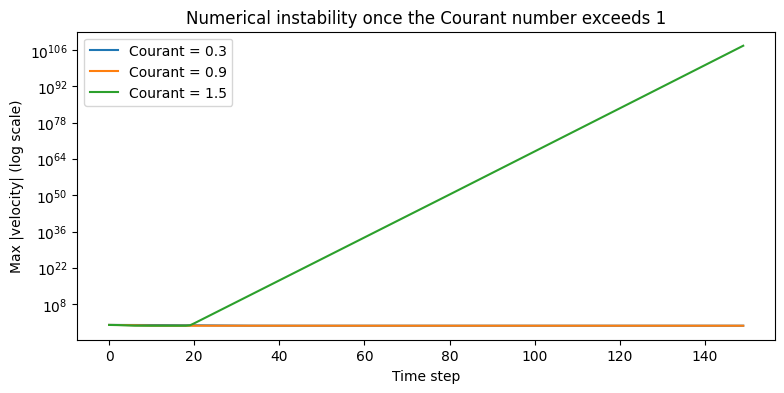

In [12]:
fig, ax = plt.subplots()
for courant_number in [0.3, 0.9, 1.5]:
    amp = run_sh_simulation(courant_number)
    ax.semilogy(amp, label=f"Courant = {courant_number}")
ax.set_xlabel("Time step")
ax.set_ylabel("Max |velocity| (log scale)")
ax.legend()
ax.set_title("Numerical instability once the Courant number exceeds 1")
plt.show()

This is exactly why the time step in Part 3 was chosen as `courant * dx / c_local.max()` with `courant = 0.5` — safely under the CFL limit of 1, with margin to spare.

## Summary & Further Resources

- **Green's functions** — the response to a point source, convolved with any source function, builds the general solution: `u = np.sum(f * G) * dx`.
- **Finite differences** — forward/backward differences are $O(\Delta x)$; central differences and the standard second-derivative formula are $O(\Delta x^2)$ — confirmed here by direct log-log error fitting.
- **Staggered-grid simulation** — storing velocity and stress at offset grid points (exactly as derived in lecture) gives a working, from-scratch elastic wave simulator in well under 20 lines of update code.
- **Stability** — the CFL condition `c*dt/dx <= 1` is not optional; violating it causes exponential blow-up, as shown directly above.

**For further reading:**
- Moczo, P., et al. (2007), *The Finite-Difference Modelling of Earthquake Motions: Waves and Ruptures* — a standard reference for staggered-grid elastic FD methods.
- Virieux, J. (1984), *SH-wave propagation in heterogeneous media: velocity-stress finite-difference method*, Geophysics 49(11) — the original staggered-grid SH scheme this notebook implements.
- SPECFEM3D / SPECFEM2D (spectral-element codes), and SW4 (a modern finite-difference code) for production-quality synthetic seismogram tools.